# <center>**Figure 2 Supplementary 05: Compartment Synaptic Density**</center>

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")
from prats_helpers import place_panel_label

In [2]:
linewidth      = 0.75
scatter_size   = 6
scatter_alpha  = 0.75
linewidth_hist = 0.5
alpha_hist     = 0.35
title_fontsize = 8.5
label_fontsize = 7
tick_fontsize  = 6
labelpad       = 10

# Labels
label_kwargs = dict(fontsize = 16, va = "center", ha = "left")

# Output Folder
FOLDER = "../Figures/Figure_02"

Loading in the Density DataFrames

In [3]:
density1_df = pd.read_parquet("../Analysis_Outputs/Density/Compartment_Density_level1.parquet")
density2_df = pd.read_parquet("../Analysis_Outputs/Density/Compartment_Density_level2.parquet")

# Remove VNC and SEZ
density1_df = density1_df.loc[~density1_df["Compartment"].str.contains("neu")]
density2_df = density2_df.loc[~density2_df["Compartment"].str.contains("neu")]

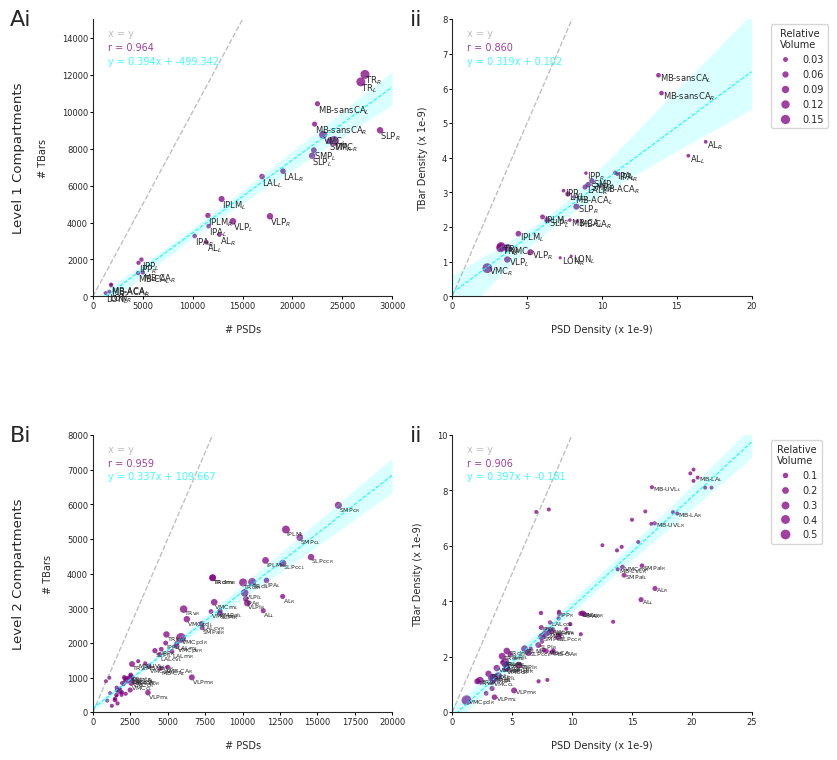

In [ ]:
fig, ax = plt.subplots(figsize = (8.5, 9), nrows = 2, ncols = 2)
plt.subplots_adjust(wspace = 0.2, hspace = 0.5)

#---------------------------------------------------------
# Level 1
# Limits
ax[0, 0].set_xlim(0, 30000)
ax[0, 0].set_ylim(0, 15000)

# Scatter with size mapped to a column
sns.scatterplot(
    data      = density1_df,
    x         = "Num_PSDs",
    y         = "Num_TBars",
    size      = "Vol_Norm",
    sizes     = (8, 50),
    color     = "purple",
    alpha     = scatter_alpha,
    edgecolor = "none",
    legend    = False,
    ax        = ax[0, 0])

# Regression line only
sns.regplot(
    data     = density1_df,
    x        = "Num_PSDs",
    y        = "Num_TBars",
    ax       = ax[0, 0],
    scatter  = False,
    line_kws = {"color": "cyan", "linewidth" : linewidth, "linestyle": "--"},
    truncate = False)

# Labels
ax[0, 0].set_xlabel("# PSDs", fontsize = label_fontsize, labelpad = 10)
ax[0, 0].set_ylabel("# TBars", fontsize = label_fontsize, labelpad = 10)
# Fit
slope, intercept, r_val, p_val, stderr = linregress(
    density1_df["Num_PSDs"],
    density1_df["Num_TBars"])

xmax = ax[0, 0].get_xlim()[-1]
ymax = ax[0, 0].get_ylim()[-1]
ax[0, 0].text(xmax * 0.05, ymax * 0.9, f"r = {r_val:.3f}", color = "purple", alpha = 0.75,
        fontsize = label_fontsize,
        ha = "left", va = "center")
ax[0, 0].text(xmax * 0.05, ymax * 0.85, f"y = {slope:.3f}x + {intercept:.3f}", color = "cyan", alpha = 0.75,
        fontsize = label_fontsize,
        ha = "left", va = "center")

# Limits
ax[0, 1].set_xlim(0, 20)
ax[0, 1].set_ylim(0, 8)
# Scatter with size mapped to a column
sns.scatterplot(
    data      = density1_df,
    x         = "PSD_Vol_Norm",
    y         = "TBar_Vol_Norm",
    size      = "Vol_Norm",
    sizes     = (5, 50),
    color     = "purple",
    alpha     = scatter_alpha,
    edgecolor = "none",
    legend    = True,
    ax        = ax[0, 1])

# Regression line only
sns.regplot(
    data     = density1_df,
    x        = "PSD_Vol_Norm",
    y        = "TBar_Vol_Norm",
    ax       = ax[0, 1],
    scatter  = False,
    line_kws = {"color": "cyan", "linewidth" : linewidth, "linestyle": "--"},
    truncate = False)

# Labels
ax[0, 1].set_xlabel("PSD Density (x 1e-9)", fontsize = label_fontsize, labelpad = 10)
ax[0, 1].set_ylabel("TBar Density (x 1e-9)", fontsize = label_fontsize, labelpad = 10)
ax[0, 1].set_xticks([0, 5, 10, 15, 20])

# Fit
slope, intercept, r_val, p_val, stderr = linregress(
    density1_df["PSD_Vol_Norm"],
    density1_df["TBar_Vol_Norm"])

xmax = ax[0, 1].get_xlim()[-1]
ymax = ax[0, 1].get_ylim()[-1]
ax[0, 1].text(xmax * 0.05, ymax * 0.9, f"r = {r_val:.3f}", color = "purple", alpha = 0.75,
        fontsize = label_fontsize,
        ha = "left", va = "center")
ax[0, 1].text(xmax * 0.05, ymax * 0.85, f"y = {slope:.3f}x + {intercept:.3f}", color = "cyan", alpha = 0.75,
        fontsize = label_fontsize,
        ha = "left", va = "center")


#---------------------------------------------------------
# Level 2
# Limits
ax[1, 0].set_xlim(0, 20000)
ax[1, 0].set_ylim(0, 8000)

# Scatter with size mapped to a column
sns.scatterplot(
    data      = density2_df,
    x         = "Num_PSDs",
    y         = "Num_TBars",
    size      = "Vol_Norm",
    sizes     = (8, 50),
    color     = "purple",
    alpha     = scatter_alpha,
    edgecolor = "none",
    legend    = False,
    ax        = ax[1, 0])

# Regression line only
sns.regplot(
    data     = density2_df,
    x        = "Num_PSDs",
    y        = "Num_TBars",
    ax       = ax[1, 0],
    scatter  = False,
    line_kws = {"color": "cyan", "linewidth" : linewidth, "linestyle": "--"},
    truncate = False)

# Labels
ax[1, 0].set_xlabel("# PSDs", fontsize = label_fontsize, labelpad = 10)
ax[1, 0].set_ylabel("# TBars", fontsize = label_fontsize, labelpad = 10)

# Fit
slope, intercept, r_val, p_val, stderr = linregress(
    density2_df["Num_PSDs"],
    density2_df["Num_TBars"])

xmax = ax[1, 0].get_xlim()[-1]
ymax = ax[1, 0].get_ylim()[-1]
ax[1, 0].text(xmax * 0.05, ymax * 0.9, f"r = {r_val:.3f}", color = "purple", alpha = 0.75,
        fontsize = label_fontsize,
        ha = "left", va = "center")
ax[1, 0].text(xmax * 0.05, ymax * 0.85, f"y = {slope:.3f}x + {intercept:.3f}", color = "cyan", alpha = 0.75,
        fontsize = label_fontsize,
        ha = "left", va = "center")


# Limits
ax[1, 1].set_xlim(0, 25)
ax[1, 1].set_ylim(0, 10)
# Scatter with size mapped to a column
sns.scatterplot(
    data      = density2_df,
    x         = "PSD_Vol_Norm",
    y         = "TBar_Vol_Norm",
    size      = "Vol_Norm",
    sizes     = (8, 50),
    color     = "purple",
    alpha     = scatter_alpha,
    edgecolor = "none",
    legend    = True,
    ax        = ax[1, 1])

# Regression line only
sns.regplot(
    data     = density2_df,
    x        = "PSD_Vol_Norm",
    y        = "TBar_Vol_Norm",
    ax       = ax[1, 1],
    scatter  = False,
    line_kws = {"color": "cyan", "linewidth" : linewidth, "linestyle": "--"},
    truncate = False)

# Labels
ax[1, 1].set_xlabel("PSD Density (x 1e-9)", fontsize = label_fontsize, labelpad = 10)
ax[1, 1].set_ylabel("TBar Density (x 1e-9)", fontsize = label_fontsize, labelpad = 10)

# Fit
slope, intercept, r_val, p_val, stderr = linregress(
    density2_df["PSD_Vol_Norm"],
    density2_df["TBar_Vol_Norm"])

xmax = ax[1, 1].get_xlim()[-1]
ymax = ax[1, 1].get_ylim()[-1]
ax[1, 1].text(xmax * 0.05, ymax * 0.9, f"r = {r_val:.3f}", color = "purple", alpha = 0.75,
        fontsize = label_fontsize,
        ha = "left", va = "center")
ax[1, 1].text(xmax * 0.05, ymax * 0.85, f"y = {slope:.3f}x + {intercept:.3f}", color = "cyan", alpha = 0.75,
        fontsize = label_fontsize,
        ha = "left", va = "center")

# Legends 
ax[1, 1].legend(loc = "upper left", bbox_to_anchor = (1.05, 1), 
                title = "Relative\nVolume",
                fontsize = label_fontsize,
                title_fontsize = label_fontsize)
ax[0, 1].legend(loc = "upper left", bbox_to_anchor = (1.05, 1), 
            title = "Relative\nVolume",
            fontsize = label_fontsize,
            title_fontsize = label_fontsize)

# Common
for a in ax.flatten():
    # Equality
    a.plot([0, 30000], [0, 30000],
            linestyle = "--",
            linewidth = 1,
            color     = "grey",
            alpha     = 0.5)
    # Ticks
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 2,
        width     = 0.75,
        pad       = 1.5)
    # Line
    xmax = a.get_xlim()[-1]
    ymax = a.get_ylim()[-1]
    # Text
    a.text(xmax * 0.05, ymax * 0.95, "x = y", color = "grey", alpha = 0.5,
           fontsize = label_fontsize,
           ha = "left", va = "center")

    # Despine
    sns.despine(ax = a)

# Adding the labels
for i, row in density1_df.iterrows():
    # Level 1
    ax[0, 0].text(row["Num_PSDs"] + 10, row["Num_TBars"] + 10,
                  row["Compartment"].replace("_Left", "$_{L}$").replace("_Right", "$_{R}$"), 
                  fontsize = tick_fontsize,
                  ha = "left", va = "top")
    
    ax[0, 1].text(row["PSD_Vol_Norm"] + 0.1, row["TBar_Vol_Norm"] + 0.1,
                  row["Compartment"].replace("_Left", "$_{L}$").replace("_Right", "$_{R}$"), 
                  fontsize = tick_fontsize,
                  ha = "left", va = "top")

# Adding the labels
for i, row in density2_df.sort_values(by = "Num_PSDs", ascending = False)[:48].iterrows():
    # Level 2
    ax[1, 0].text(row["Num_PSDs"] + 10, row["Num_TBars"] + 10,
                  row["Compartment"].replace("_Left", "$_{L}$").replace("_Right", "$_{R}$"), 
                  fontsize = tick_fontsize - 1.5,
                  ha = "left", va = "top")
    
    ax[1, 1].text(row["PSD_Vol_Norm"] + 0.1, row["TBar_Vol_Norm"] + 0.1,
                  row["Compartment"].replace("_Left", "$_{L}$").replace("_Right", "$_{R}$"), 
                  fontsize = tick_fontsize - 1.5,
                  ha = "left", va = "top")

# Titles
ax[0, 0].text(-7500, 7500,
              "Level 1 Compartments",
              fontsize = title_fontsize + 1,
              ha = "center",
              va = "center",
              rotation = 90)

ax[1, 0].text(-5000, 4000,
              "Level 2 Compartments",
              fontsize = title_fontsize + 1,
              ha = "center",
              va = "center",
              rotation = 90)


# Panel Labels
place_panel_label(fig, ax[0, 0], "Ai", shx = -0.0975, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[0, 1], "ii", shx = -0.0500, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 0], "Bi", shx = -0.0975, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 1], "ii", shx = -0.0500, shy = 0, label_kwargs = label_kwargs)


#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_02_Supplementary-06_Compartment-Synaptic-Density.pdf",
            dpi = 1200,
            bbox_inches = "tight")

# <center>**हो गया दोस्तों!**</center>